In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, CategoricalNB, ComplementNB, BernoulliNB
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [4]:
# Combine all PDBs into a single dataframe
dfs = []
for filename in os.listdir('data/features_ring'):
    dfs.append(pd.read_csv('data/features_ring/' + filename, sep='\t'))
df = pd.concat(dfs)

# Create a new class 'Missing' for unclassified contacts
df['Interaction'] = df['Interaction'].fillna('Missing')
df

,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_phi,t_psi,t_a1,t_a2,t_a3,t_a4,t_a5,t_3di_state,t_3di_letter,Interaction
0,1u9c,A,71,,A,H,0.434,-1.145,-0.683,-0.591,...,-2.580,1.037,0.336,-0.417,-1.673,-1.474,-0.078,5.0,F,Missing
1,1u9c,A,172,,S,H,0.354,-1.001,-0.749,-0.228,...,-1.036,-0.619,-1.019,-0.987,-1.505,1.266,-0.912,17.0,R,HBOND
2,1u9c,A,172,,S,H,0.354,-1.001,-0.749,-0.228,...,-1.036,-0.619,-1.019,-0.987,-1.505,1.266,-0.912,17.0,R,VDW
3,1u9c,A,155,,E,H,0.351,-1.048,-0.782,1.357,...,-1.153,-0.666,1.538,-0.055,1.502,0.440,2.897,17.0,R,Missing
4,1u9c,A,184,,G,-,0.250,-2.102,-3.018,-0.384,...,-1.486,-0.626,0.931,-0.179,-3.005,-0.503,-1.853,19.0,T,HBOND
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,3vrd,A,160,,E,H,0.490,-1.159,-0.613,1.357,...,-1.092,-0.789,-1.019,-0.987,-1.505,1.266,-0.912,17.0,R,HBOND
1036,3vrd,A,160,,E,H,0.490,-1.159,-0.613,1.357,...,-1.092,-0.789,-1.019,-0.987,-1.505,1.266,-0.912,17.0,R,VDW
1037,3vrd,B,135,,A,H,0.142,-1.049,-0.835,-0.591,...,-1.135,-0.709,1.538,-0.055,1.502,0.440,2.897,15.0,P,Missing
1038,3vrd,B,236,,T,E,0.225,-2.200,2.770,-0.032,...,-2.231,2.306,-1.006,-0.590,1.891,-0.397,0.412,2.0,C,Missing


In [5]:
# Remove all rows with NaN in at least one column
df.dropna(inplace=True)

# Define ground truth values
y = df['Interaction'].astype('category')

In [6]:
# Define training features
columns = ['s_ss8', 's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5', 's_3di_state', 's_3di_letter',
               't_ss8', 't_rsa', 't_phi', 't_psi', 't_a1','t_a2', 't_a3', 't_a4', 't_a5', 't_3di_state', 't_3di_letter']

X = df[columns]

# Calculate percentiles and transform into categories
X = X.rank(pct=True).round(1).astype('category') 
X

,s_ss8,s_rsa,s_phi,s_psi,s_a1,s_a2,s_a3,s_a4,s_a5,s_3di_state,...,t_rsa,t_phi,t_psi,t_a1,t_a2,t_a3,t_a4,t_a5,t_3di_state,t_3di_letter
0,0.6,0.9,0.6,0.3,0.4,0.1,0.4,1.0,0.5,0.9,...,1.0,0.0,0.6,0.7,0.4,0.2,0.0,0.5,0.2,0.2
1,0.6,0.8,0.9,0.2,0.5,0.9,0.0,0.6,0.1,0.9,...,1.0,0.8,0.4,0.2,0.2,0.2,0.9,0.3,0.9,0.9
2,0.6,0.8,0.9,0.2,0.5,0.9,0.0,0.6,0.1,0.9,...,1.0,0.8,0.4,0.2,0.2,0.2,0.9,0.3,0.9,0.9
3,0.6,0.8,0.8,0.2,0.9,0.1,0.7,0.4,0.4,0.9,...,0.9,0.6,0.3,0.9,0.6,0.7,0.6,1.0,0.9,0.9
4,0.1,0.7,0.2,0.0,0.4,0.9,0.6,0.7,0.9,0.2,...,0.1,0.4,0.4,0.7,0.5,0.1,0.2,0.1,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,0.6,0.9,0.6,0.4,0.9,0.1,0.7,0.4,0.4,0.6,...,0.3,0.7,0.1,0.2,0.2,0.2,0.9,0.3,0.9,0.9
1036,0.6,0.9,0.6,0.4,0.9,0.1,0.7,0.4,0.4,0.6,...,0.3,0.7,0.1,0.2,0.2,0.2,0.9,0.3,0.9,0.9
1037,0.6,0.6,0.8,0.1,0.4,0.1,0.4,1.0,0.5,0.9,...,0.6,0.6,0.3,0.9,0.6,0.7,0.6,1.0,0.7,0.7
1038,0.3,0.7,0.1,0.9,0.5,0.7,0.9,0.7,0.8,1.0,...,0.5,0.1,0.8,0.3,0.3,0.8,0.2,0.6,0.1,0.1


In [7]:
# Split the dataset to define training and testing examples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)
y_test.value_counts()

Interaction
Missing      106348
HBOND        102868
VDW           71339
PIPISTACK      3847
IONIC          3480
PICATION        817
SSBOND          187
PIHBOND         157
Name: count, dtype: int64

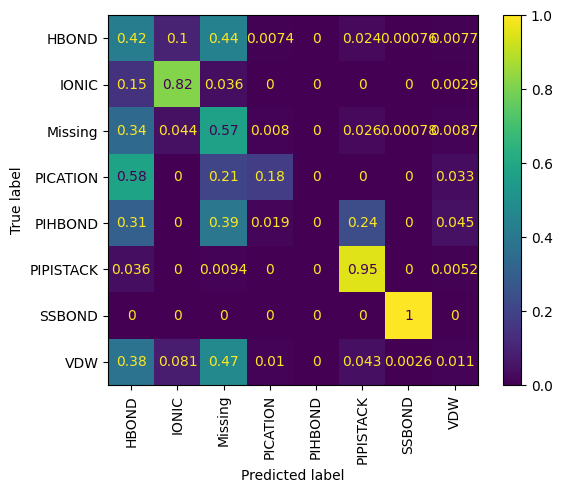

In [9]:
nb = GaussianNB()
y_pred = nb.fit(X_train, y_train).predict(X_test)
cm = confusion_matrix(y_test,y_pred, normalize='true')
plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
plot.plot(xticks_rotation='vertical')

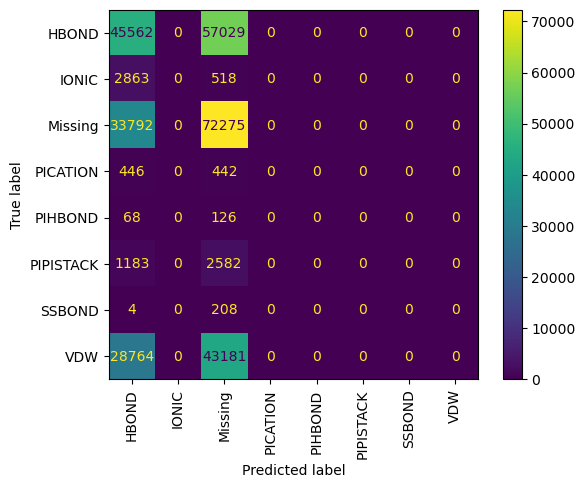

In [ ]:
nb = MultinomialNB()
y_pred = nb.fit(X_train, y_train).predict(X_test)
cm = confusion_matrix(y_test,y_pred) #, normalize='true')
plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
plot.plot(xticks_rotation='vertical')

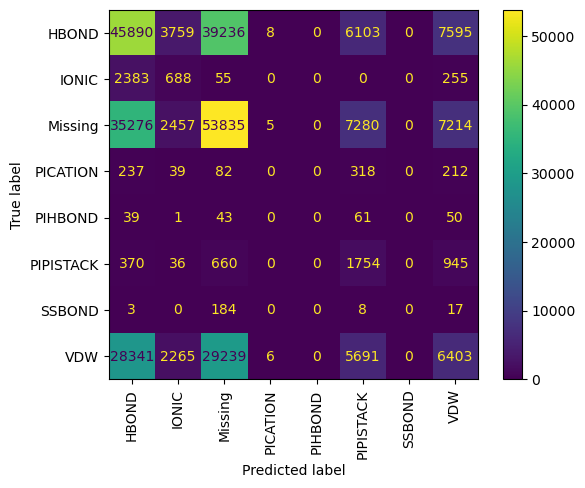

In [ ]:
nb = ComplementNB()
y_pred = nb.fit(X_train, y_train).predict(X_test)
cm = confusion_matrix(y_test,y_pred) #, normalize='true')
plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
plot.plot(xticks_rotation='vertical')

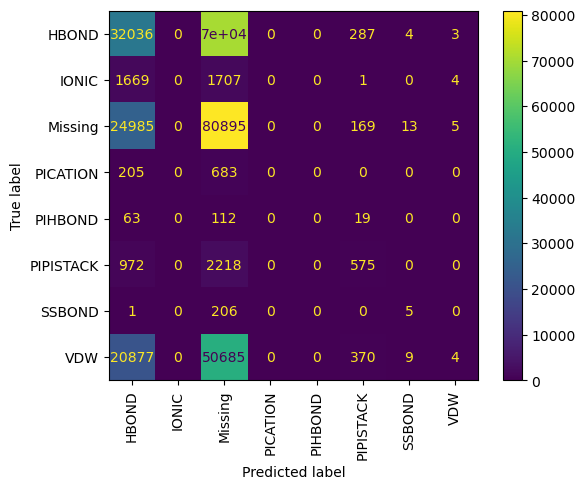

In [ ]:
nb = BernoulliNB()
y_pred = nb.fit(X_train, y_train).predict(X_test)
cm = confusion_matrix(y_test,y_pred) #, normalize='true')
plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
plot.plot(xticks_rotation='vertical')

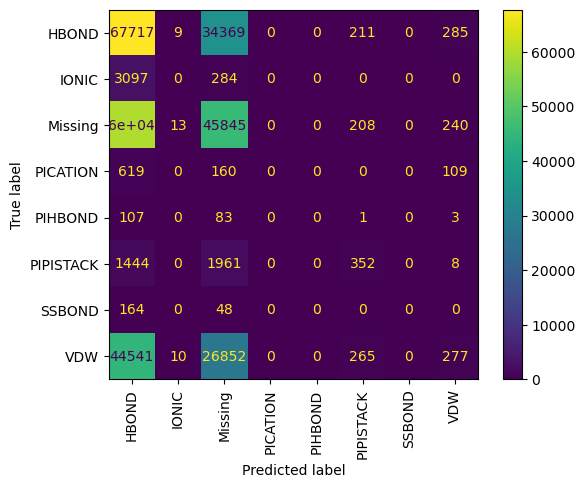

In [ ]:
nb = CategoricalNB()
y_pred = nb.fit(X_train, y_train).predict(X_test)
cm = confusion_matrix(y_test,y_pred) #, normalize='true')
plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
plot.plot(xticks_rotation='vertical')